In [198]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as sci

%matplotlib inline

In [ ]:
S = 100
K = 100
T = 1
N = 252
dt = T / N
r = 0.05
sigma = 0.2

n_sims = 100000

T = dt * N


In [200]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))*S - sci.norm.cdf(d2(S, K, T, r, sigma))*K*np.exp(-r*T)

def delta_call(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))

In [201]:
def price_at_strike(S, K, T, r, sigma, noise):
    increments = np.exp((r - sigma**2 / 2)*T + sigma * np.sqrt(T)*noise)
    return S * np.cumprod(increments, axis=1)

In [202]:
def hedge_simulator(S, K, T, r, sigma, path, N, dt):

    
    rem_time = T - np.arange(N) * dt
    deltas = delta_call(path, K, rem_time, r, sigma)

    discount_factors = np.exp(-r * np.arange(N) * dt) 


    
    cash = - np.sum(np.diff(deltas, axis=1)*path[:, 1:] * discount_factors[1:], axis=1)

    start =  - deltas[:, 0] * path[:, 0] 
    
    end = deltas[:, -1] * path[:, -1] * np.exp(-r * T)

    cashflow = cash + start + end


    option_premium = call_price(S, K, T, r, sigma)


    option_payout = np.maximum(path[:, -1] - K, 0) * np.exp(-r * T)

    # print(f"Costs = {costs}")
    # print(f"Premium = {option_premium}")


    # print(f"Option payouts = {option_payout}")

    hedged_PnL = (option_premium + cashflow - option_payout)
    unhedged_PnL = (option_premium - option_payout)
    return hedged_PnL, unhedged_PnL, start, end, cash


In [203]:
path = price_at_strike(S, K, dt, r, sigma, np.random.randn(n_sims, N))

hedged_PnL, unhedged_PnL, start, end, cash = hedge_simulator(S, K, T, r, sigma, path, N, dt)
print(np.mean(hedged_PnL), np.mean(unhedged_PnL), np.std(hedged_PnL), np.std(unhedged_PnL), np.mean(start), np.mean(end), np.mean(cash))

-0.0141539259595668 -0.008234319172430487 0.9054953225766001 14.739229382529764 -63.71931749153858 63.715648991932326 -0.0022511071808575455


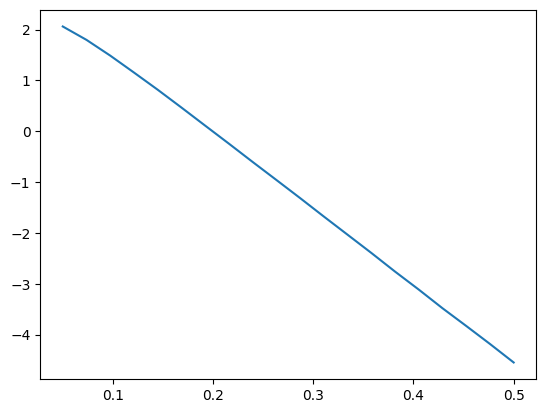

In [204]:
vols = np.linspace(0.05, 0.5, 20)
pnls = []
for v in vols:
    path = price_at_strike(S, K, dt, r, v, np.random.randn(n_sims, N))
    pnls.append(np.mean(hedge_simulator(S, K, T, r, sigma, path, N, dt)))

plt.plot(vols, pnls)

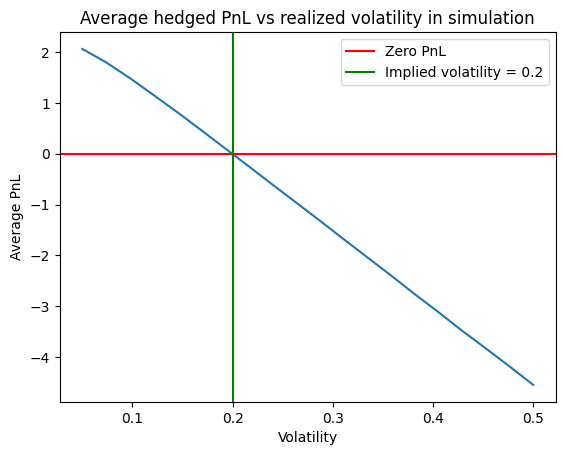

In [205]:
plt.plot(vols, pnls)
plt.axhline(0, color="red", label="Zero PnL")
plt.axvline(sigma, color="green", label=f"Implied volatility = {sigma}")
plt.xlabel("Volatility")
plt.ylabel("Average PnL")
plt.legend(loc="upper right")
plt.title("Average hedged PnL vs realized volatility in simulation")
plt.savefig("Hedged PnL vs volatility.png")

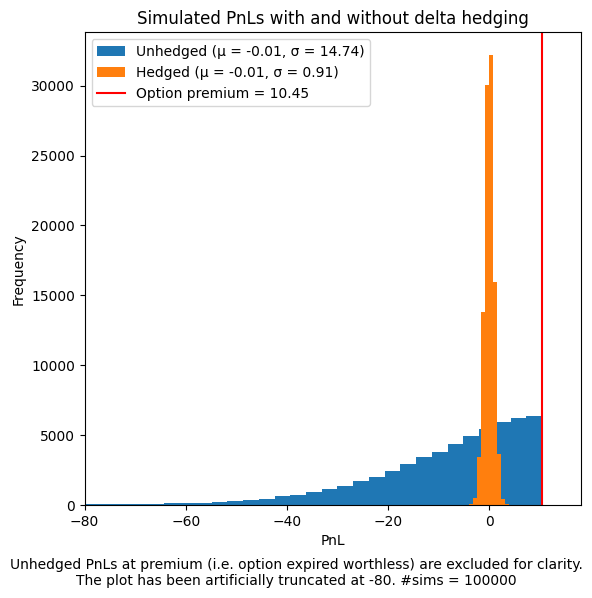

In [207]:
unhedged_PnL_clean = unhedged_PnL[np.where(~np.isclose(unhedged_PnL, call_price(S, K, T, r, sigma)))]
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(unhedged_PnL_clean, bins=50, label=f"Unhedged (μ = {np.mean(unhedged_PnL):.2f}, σ = {np.std(unhedged_PnL):.2f})")
ax.hist(hedged_PnL, label=f"Hedged (μ = {np.mean(hedged_PnL):.2f}, σ = {np.std(hedged_PnL):.2f})")
ax.axvline(call_price(S, K, T, r, sigma), color="red", label=f"Option premium = {call_price(S, K, T, r, sigma):.2f}")
# ax.axvline(np.mean(unhedged_PnL), color="blue", label="Unhedged mean")
# ax.axvline(np.mean(hedged_PnL), color="C1", label="Hedged mean")
ax.set_xlim(left=-80)
ax.legend(loc="upper left")
ax.set_xlabel("PnL")
ax.set_ylabel("Frequency")
ax.set_title(f"Simulated PnLs with and without delta hedging")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.02, f"Unhedged PnLs at premium (i.e. option expired worthless) are excluded for clarity. The plot has been artificially truncated at -80. #sims = {n_sims}", wrap=True, horizontalalignment='center')
plt.savefig("Hedged vs Unhedged PnL.png")
plt.show()

